# **Heart Disease Predicting**

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

#### Data Load

In [3]:
train_ds = pd.read_csv("Data/train.csv")
test_ds = pd.read_csv("Data/test.csv")

print("Train dataset:", train_ds.shape)
print("Test dataset:", test_ds.shape)

Train dataset: (630000, 15)
Test dataset: (270000, 14)


In [4]:
train_ds.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

#### Data Preprocessing

In [6]:
# check missing values
train_ds.isnull().sum() 

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [7]:
# Check duplicates values
train_ds.duplicated().sum()

0

#### Outlier detection

In [8]:
train_ds.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [9]:
train_ds.head(3)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence


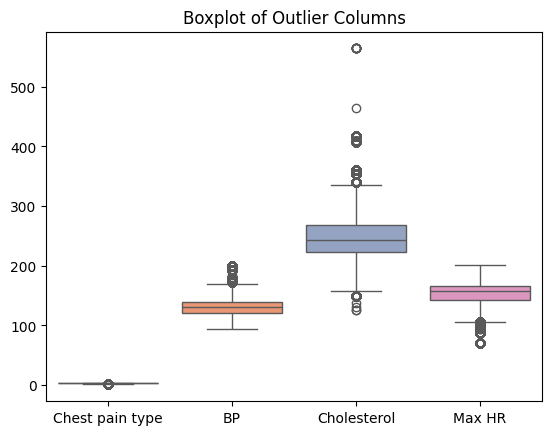

In [10]:
outlier_cols = ['Chest pain type', 'BP', 'Cholesterol', 'Max HR']

sns.boxplot(data=train_ds[outlier_cols], palette="Set2")
plt.title("Boxplot of Outlier Columns")
plt.show()

In [11]:
# ## Outliers remove using IQR method
# def remove_outliers_iqr(df, column):
#     for col in column:
#         Q1 = df[col].quantile(0.25)
#         Q3 = df[col].quantile(0.75)
#         IQR = Q3 - Q1

#         min_range = Q1 - (1.5 * IQR)
#         max_range = Q3 + (1.5 * IQR)

#         df = df[(df[col] >= min_range) & (df[col] <= max_range)]
#         return df


# ds = remove_outliers_iqr(train_ds, outlier_cols)

#### Data Visualization

In [12]:
train_ds.iloc[:, :-1]

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6


In [13]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
train_ds['Heart Disease'] = ohe.fit_transform(train_ds[['Heart Disease']])

<Axes: >

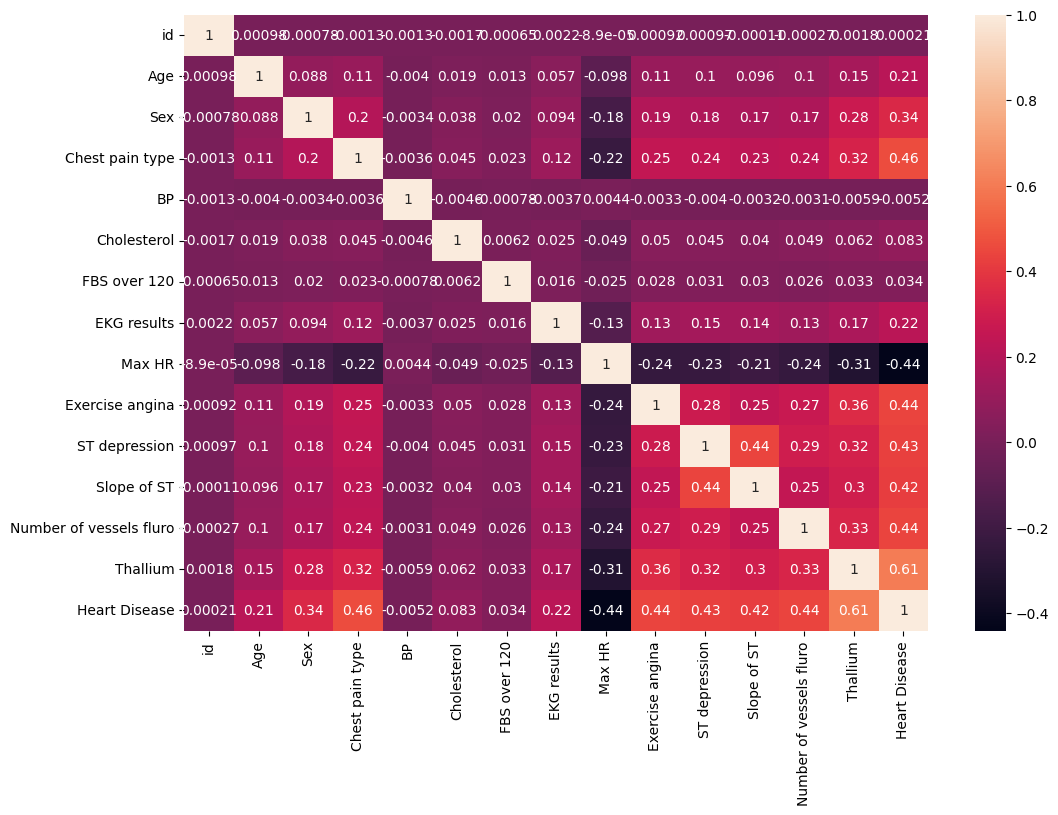

In [14]:
## Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(train_ds.corr(), annot=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_13892\1933010324.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Heart Disease', data=train_ds, palette="Set2")


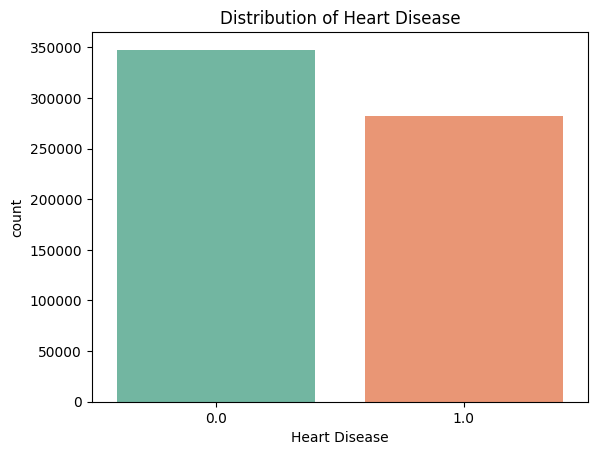

In [15]:
sns.countplot(x='Heart Disease', data=train_ds, palette="Set2")
plt.title("Distribution of Heart Disease")
plt.show()

#### Data Scaling

In [16]:
ss = StandardScaler()
x = pd.DataFrame(ss.fit_transform(train_ds.iloc[:, :-1]), columns=train_ds.columns[:-1])
y = train_ds['Heart Disease']

In [47]:
# Save scaler
joblib.dump(ss, 'scaler.pkl')

['scaler.pkl']

#### Train test split

In [17]:
x_train, x_test, y_train, y_test =  train_test_split(x, y, test_size=0.2, random_state=42)

#### Cross Validation 

In [18]:
cross_val_score(XGBClassifier(), x_train, y_train, cv=StratifiedKFold(n_splits=5))

array([0.88767857, 0.88762897, 0.88854167, 0.88703373, 0.88827381])

In [19]:
cross_val_score(LGBMClassifier(), x_train, y_train, cv=StratifiedKFold(n_splits=5))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180815, number of negative: 222385
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 678
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448450 -> initscore=-0.206936
[LightGBM] [Info] Start training from score -0.206936
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180815, number of negative: 222385
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027732 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 677
[LightGBM] [

array([0.88803571, 0.88785714, 0.88871032, 0.88714286, 0.88865079])

#### Model build and fit

#Logistic regression

In [21]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

LogisticRegression()

In [22]:
print(lr.score(x_train, y_train)*100, lr.score(x_test, y_test)*100)

88.34424603174604 88.2031746031746


#RandomForest

In [ ]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
print(rf.score(x_train, y_train)*100, rf.score(x_test, y_test)*100)

99.99642857142858 88.17857142857143


#LGBM

In [23]:
lgbm = LGBMClassifier()
lgbm.fit(x_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 226018, number of negative: 277982
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 677
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448448 -> initscore=-0.206942
[LightGBM] [Info] Start training from score -0.206942


LGBMClassifier()

In [24]:
print(lgbm.score(x_train, y_train)*100, lgbm.score(x_test, y_test)*100)

88.9327380952381 88.66904761904762


#XGBoost

In [25]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [26]:
print(xgb.score(x_train, y_train)*100, xgb.score(x_test, y_test)*100)

89.31349206349206 88.66904761904762


#Catboost

In [27]:
ctb = CatBoostClassifier(verbose=0)
ctb.fit(x_train, y_train)

In [28]:
print(ctb.score(x_train, y_train)*100, ctb.score(x_test, y_test)*100)

89.50575396825397 88.67698412698412


#### Evaluation

In [43]:
# Accuracy Score
y_prd = lgbm.predict(x_test)
print("Accuracy Score:", accuracy_score(y_test, y_prd)*100)

Accuracy Score: 88.66904761904762


In [44]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_prd))

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      0.90      0.90     69564
         1.0       0.88      0.87      0.87     56436

    accuracy                           0.89    126000
   macro avg       0.89      0.88      0.89    126000
weighted avg       0.89      0.89      0.89    126000



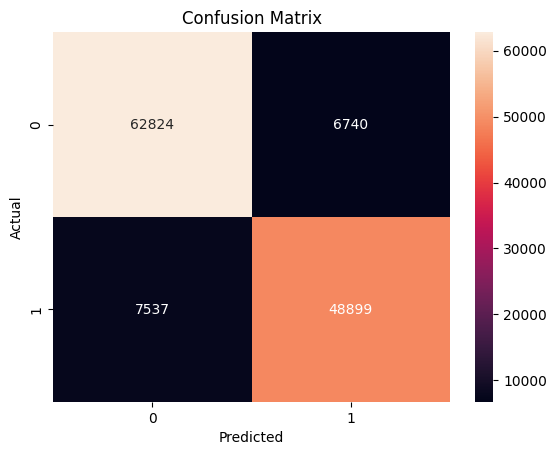

In [45]:
sns.heatmap(confusion_matrix(y_test, y_prd), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Create submission file 

In [51]:
scaler = joblib.load('scaler.pkl')
test_ds_scaled = scaler.transform(test_ds)

test_ds_scaled.shape 

(270000, 14)

In [55]:
final_prd = lgbm.predict(test_ds_scaled)

submission = pd.DataFrame({
    'id': test_ds['id'],
    'Heart Disease': final_prd
}).reset_index(drop=True)

C:\Users\USER\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [57]:
submission.head()

,id,Heart Disease
0,630000,1.0
1,630001,0.0
2,630002,1.0
3,630003,0.0
4,630004,0.0


In [58]:
submission.to_csv('submission.csv', index=False)
print("Submission file created successfully!")

Submission file created successfully!
